In [1]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [3]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [9]:
from numpy import diff


chem_pots = np.linspace(5, 50, 100)
amplitude = np.linspace(0.01, 0.249, 100)

difference_in_mean = []

mean_data = np.mean(occupancy)

for chem_pot in chem_pots:
    for amp in amplitude:
        fiber.calc_energy_landscape(octamer=True, period=10.1, amplitude=amp, chemical_potential=chem_pot)
        lsq_occupancy = fiber.occupancy[1000:-1000] 
        x_coords = np.arange(start, end)

        difference_in_mean.append(np.mean(lsq_occupancy) - mean_data)



In [10]:
from scipy.optimize import brentq
from tqdm import tqdm

obs_mean = np.mean(occupancy)
obs_std = np.std(occupancy)
amp_values = np.linspace(0.01, 0.25, 100)

def mean_diff(mu, amp):
    fiber.calc_energy_landscape(period=10, amplitude=amp, chemical_potential=mu)
    return np.mean(fiber.occupancy[1000:-1000]) - obs_mean
    

mu_zero = []
for amp in tqdm(amp_values, desc="Finding zero contour"):
    try:
        mu_root = brentq(mean_diff, -5, 100, args=(amp,))
        mu_zero.append(mu_root)
    except ValueError:
        mu_zero.append(np.nan)

mu_zero = np.array(mu_zero)
valid = ~np.isnan(mu_zero)
print(f"Observed mean occupancy: {obs_mean:.4f}")
print(f"Found {valid.sum()} contour points")

Finding zero contour:  98%|█████████▊| 98/100 [01:00<00:01,  1.62it/s]/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:974: RuntimeWarning: divide by zero encountered in log
  log_weights = np.log(self.weight)   # shape (4, 4, w)
/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:406: RuntimeWarning: invalid value encountered in scalar subtract
  forward[i] = np.exp(free_energy[i] - sum_prev)
Finding zero contour: 100%|██████████| 100/100 [01:01<00:00,  1.64it/s]

Observed mean occupancy: 0.3923
Found 97 contour points


Exponential  a·e^(b·μ) + c  →  params=[-0.26137 -0.04412  0.23746]
Power/root   a·|μ - c|^b  →  params=[0.04419 0.39938 5.65791]


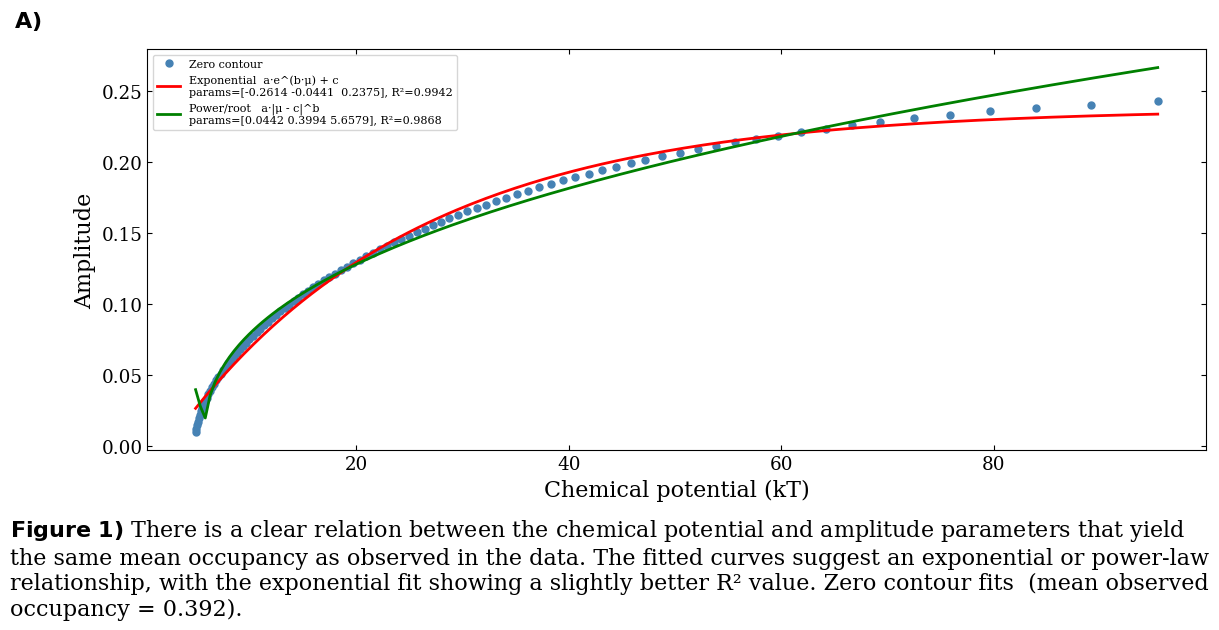

In [11]:
from scipy.optimize import curve_fit

def exp_func(mu, a, b, c):
    return a * np.exp(b * mu) + c

def root_func(mu, a, b, c):
    return a * np.power(np.abs(mu - c), b)

mu_pts = mu_zero[valid]
amp_pts = amp_values[valid]
mu_fit = np.linspace(mu_pts.min(), mu_pts.max(), 200)

fits = {}
for name, func, p0 in [
    ("Exponential  a·e^(b·μ) + c", exp_func,  [1.0, -0.1,  0.0]),
    ("Power/root   a·|μ - c|^b",   root_func, [1.0,  0.5,  0.0]),
]:
    try:
        popt, _ = curve_fit(func, mu_pts, amp_pts, p0=p0, maxfev=10000)
        residuals = amp_pts - func(mu_pts, *popt)
        r2 = 1 - np.var(residuals) / np.var(amp_pts)
        fits[name] = (func, popt, r2)
    except RuntimeError:
        print(f"{name}: fit did not converge")

plotter = Plotter(fig_size=(12, 5))
plotter.new(ncols=1, nrows=1)
ax = plotter.axes

ax.plot(mu_pts, amp_pts, 'o', color='steelblue', markersize=5, label='Zero contour')

colors = ['red', 'green']
for (name, (func, popt, r2)), color in zip(fits.items(), colors):
    ax.plot(mu_fit, func(mu_fit, *popt), '-', color=color, linewidth=2,
            label=f"{name}\nparams={np.round(popt, 4)}, R²={r2:.4f}")

ax.set_xlabel("Chemical potential (kT)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Zero contour fits  (mean observed occupancy = {obs_mean:.3f})")
ax.legend(fontsize=8)
plotter.caption(f"There is a clear relation between the chemical potential and amplitude parameters that yield the same mean occupancy as observed in the data. The fitted curves suggest an exponential or power-law relationship, with the exponential fit showing a slightly better R² value.")

for name, (func, popt, r2) in fits.items():
    print(f"{name}  →  params={np.round(popt, 5)}")


    

/home/mvenrooij/NucTool/nuctool/Plotter.py:160: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, self.axes = plt.subplots(


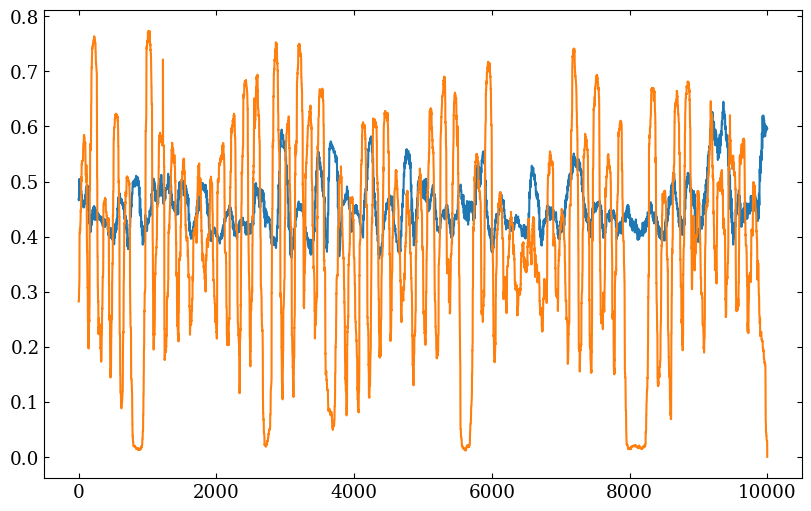

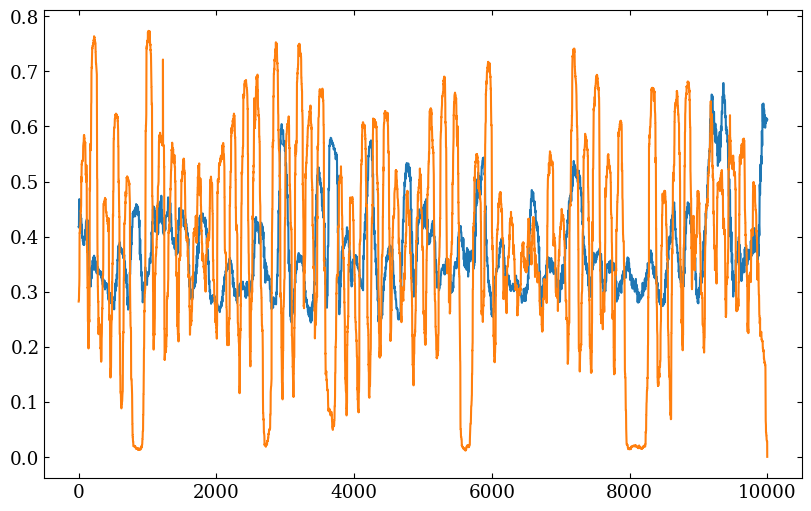

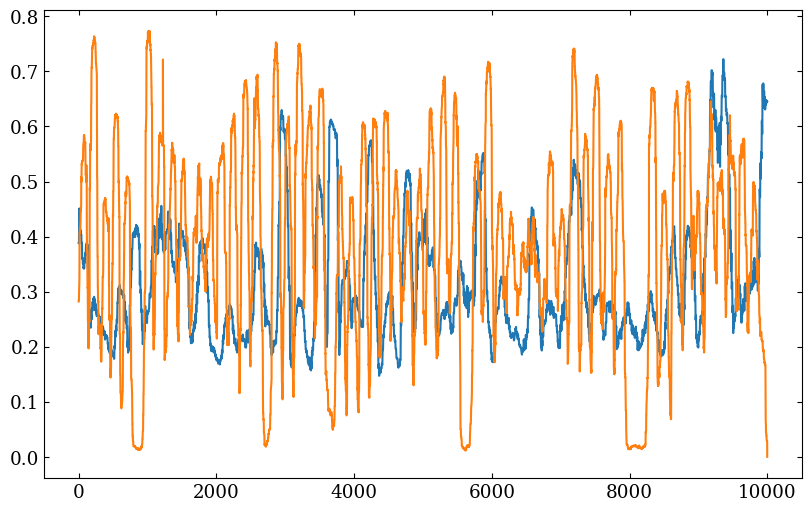

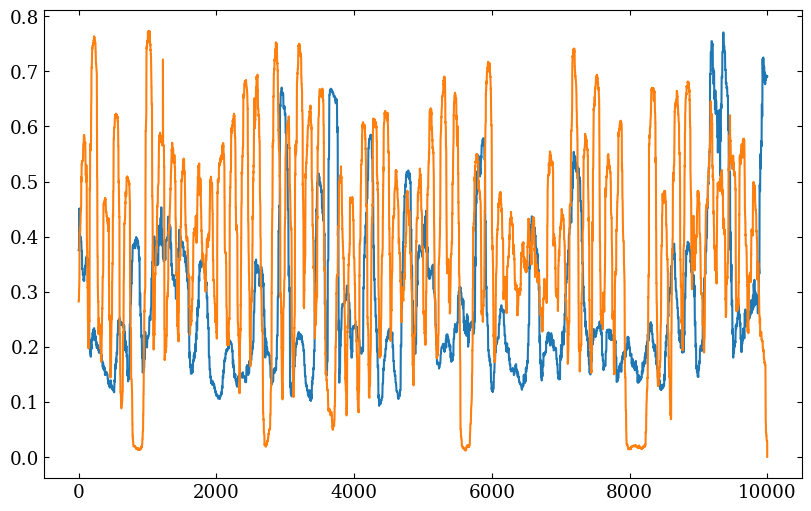

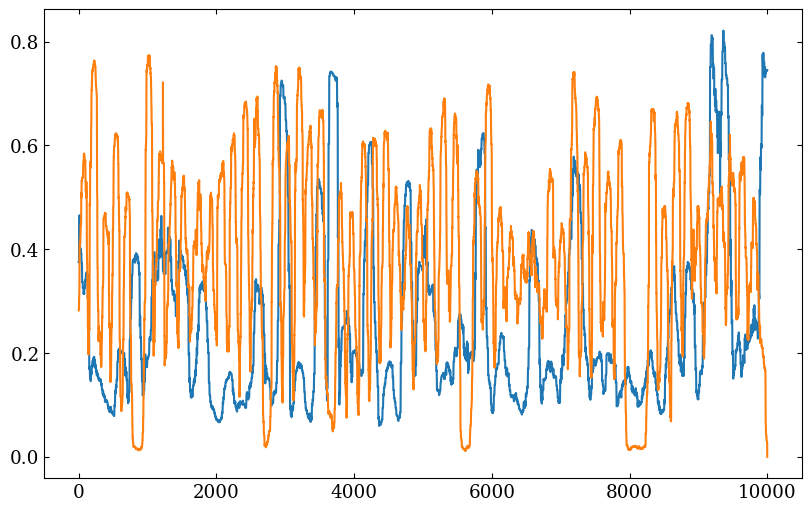

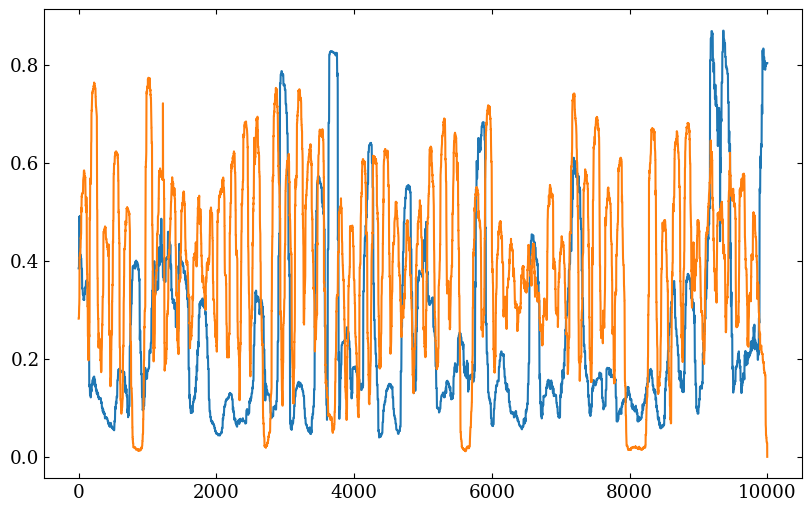

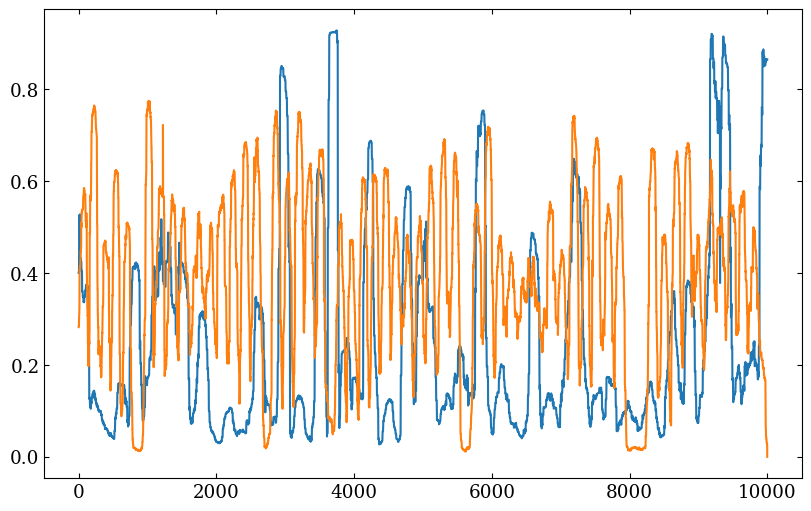

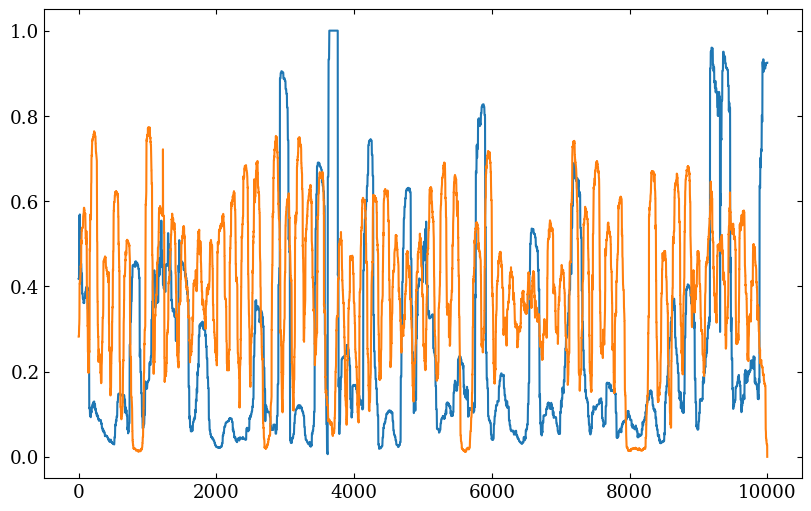

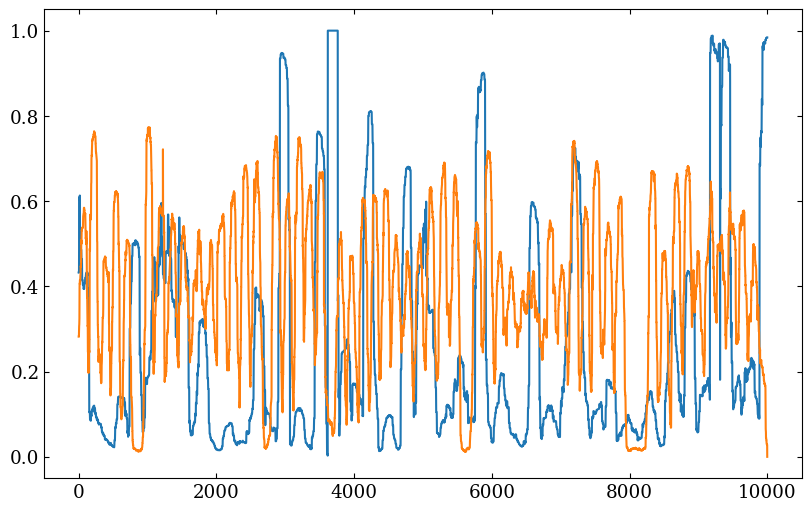

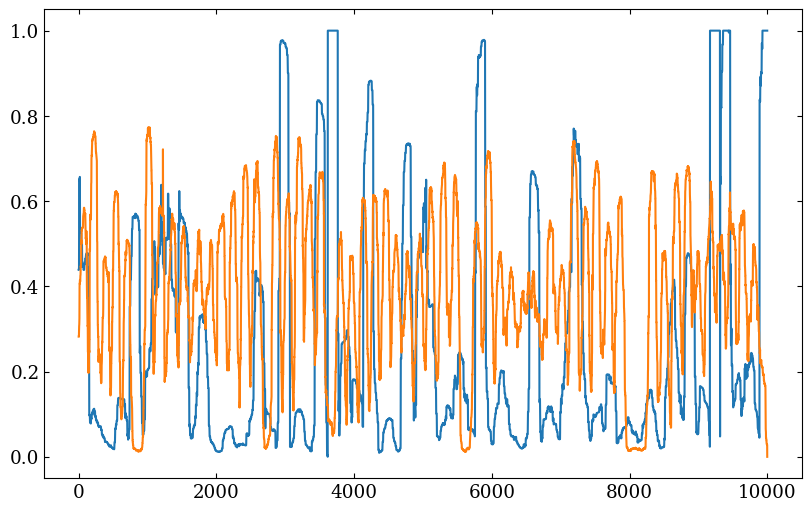

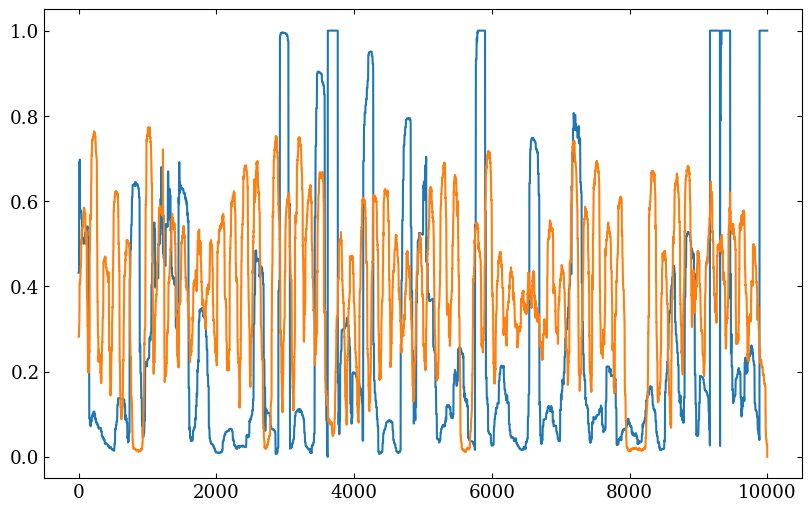

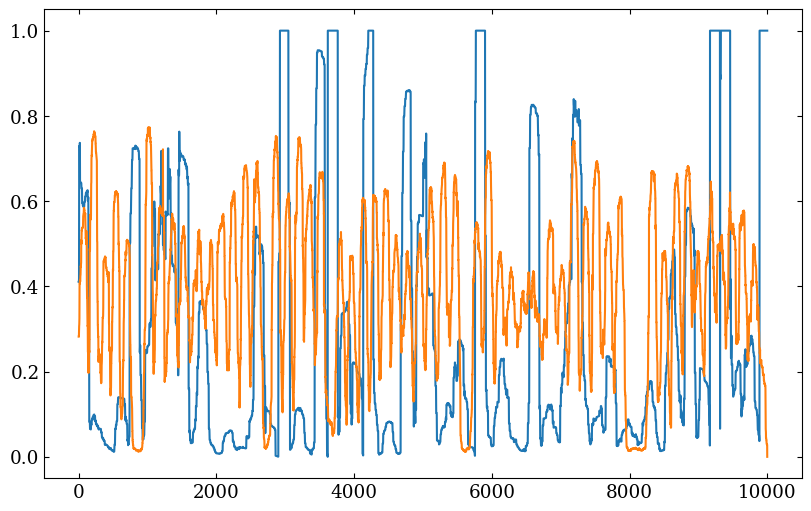

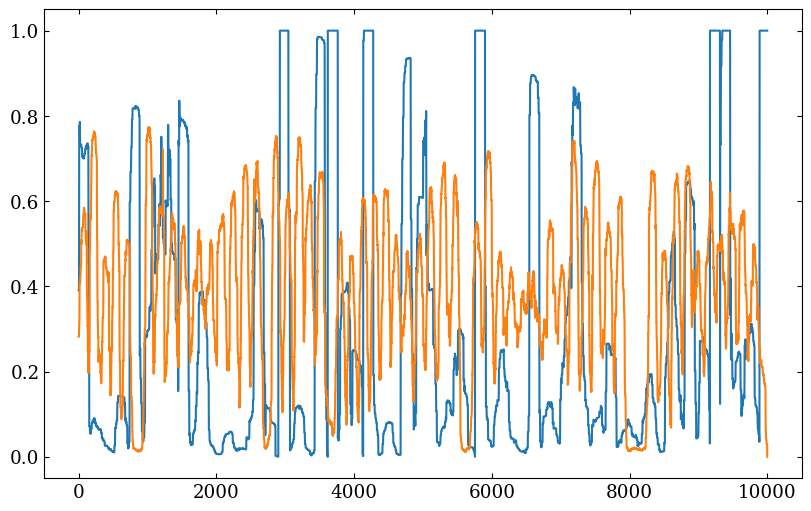

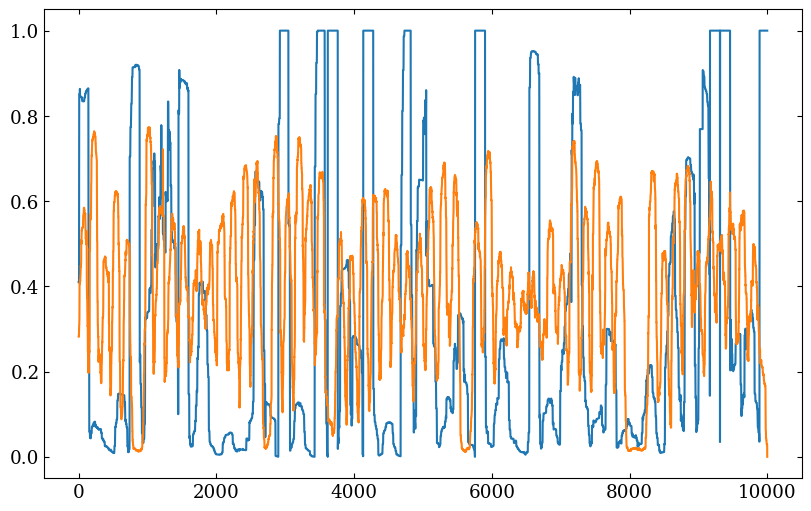

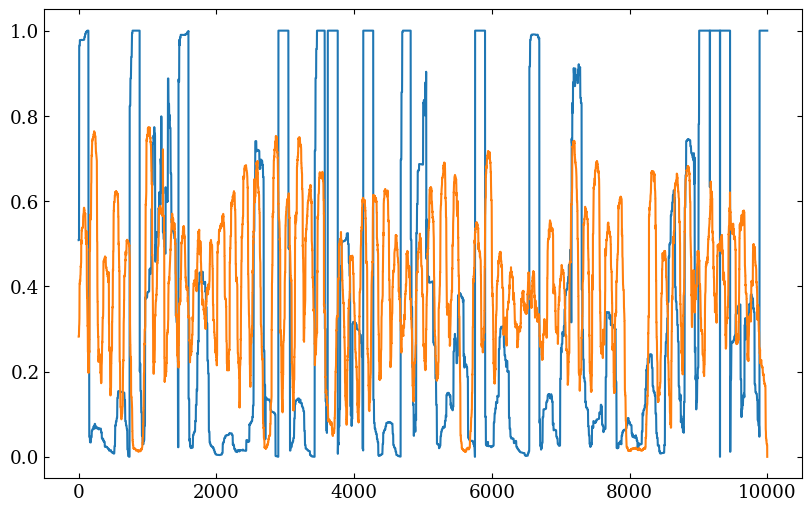

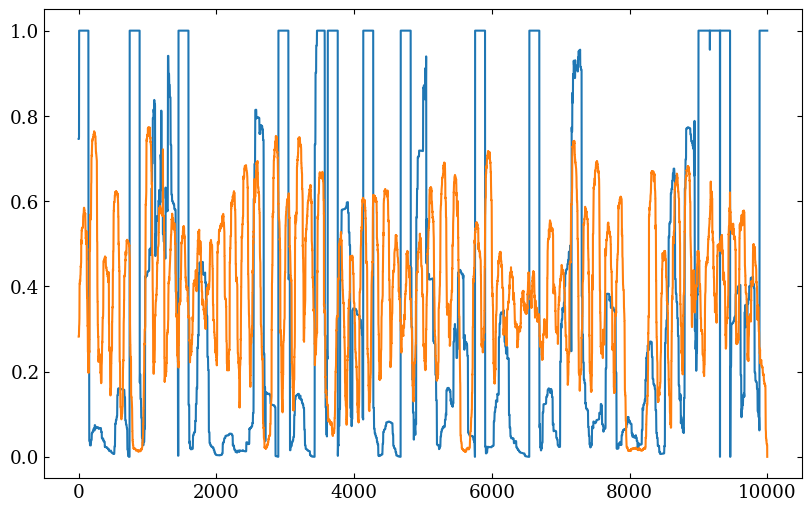

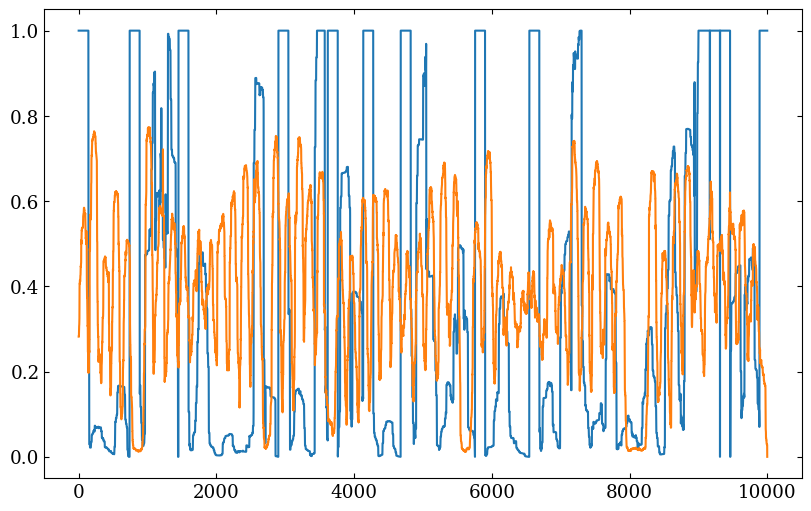

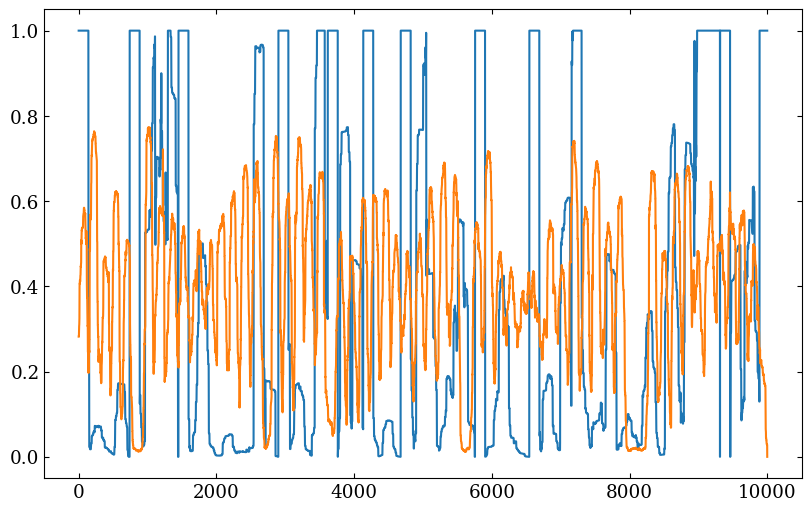

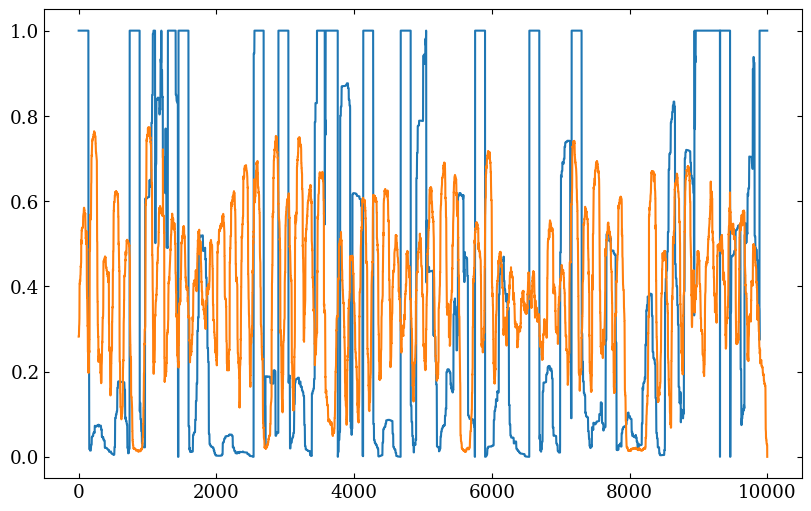

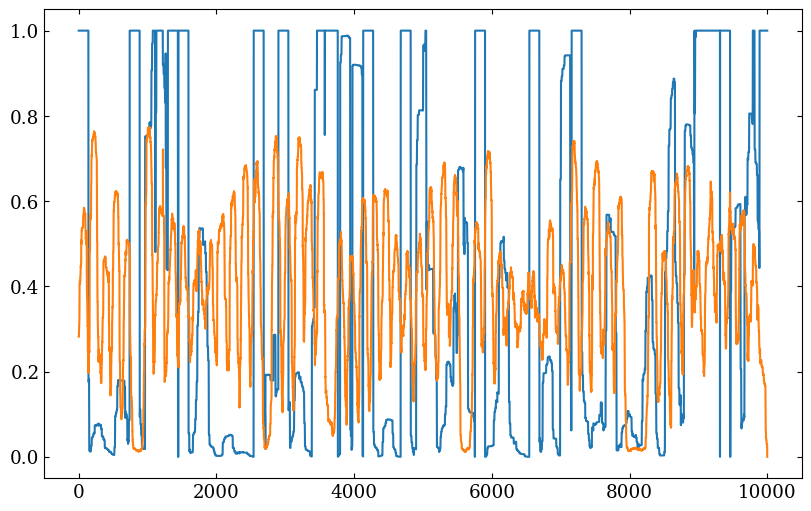

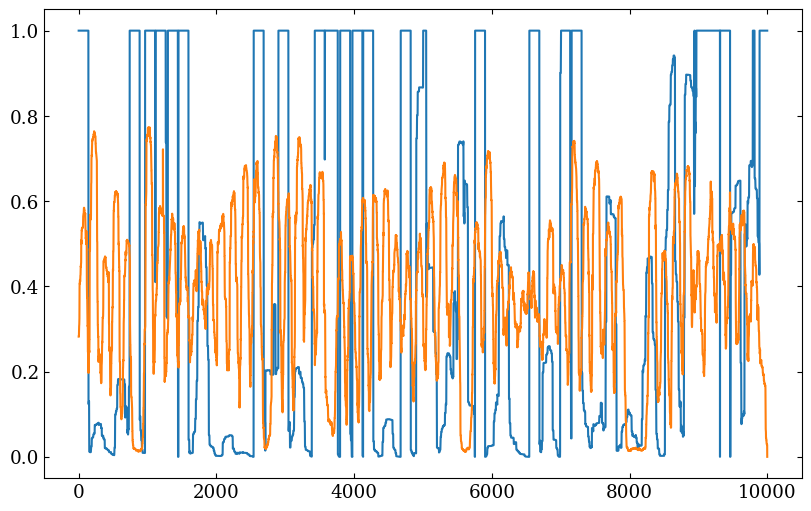

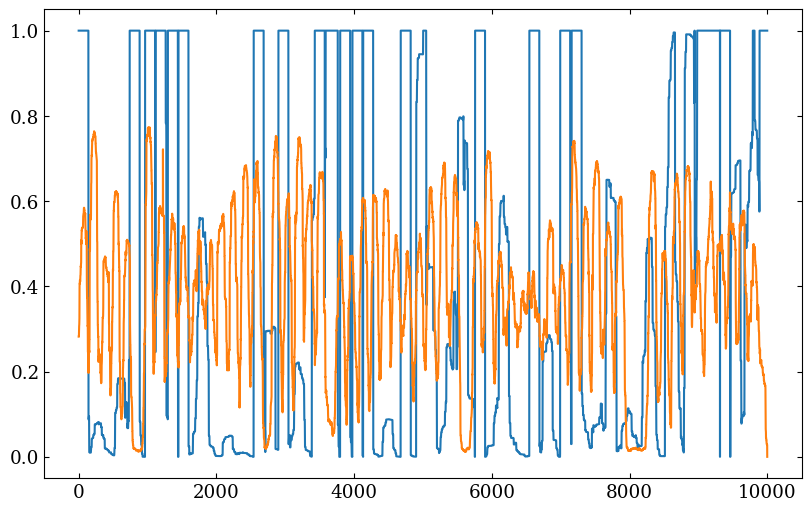

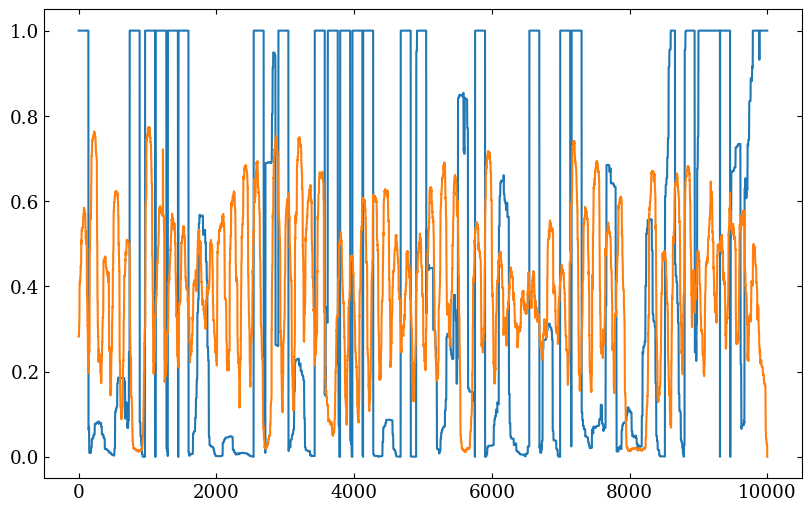

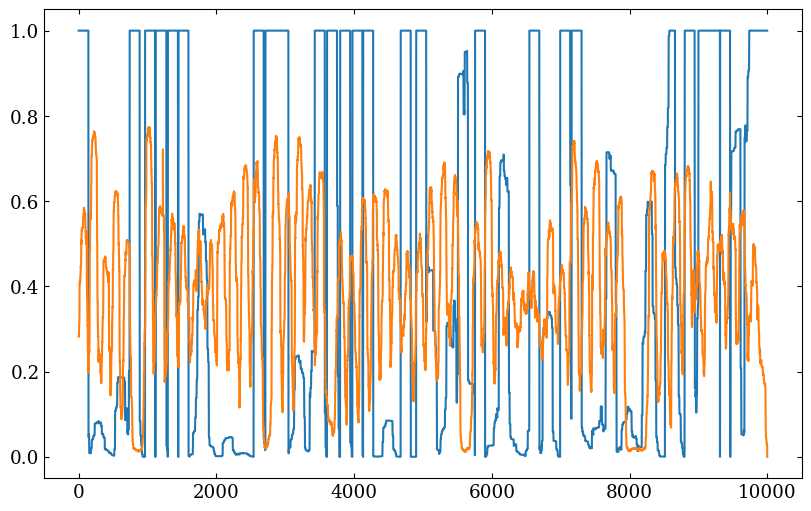

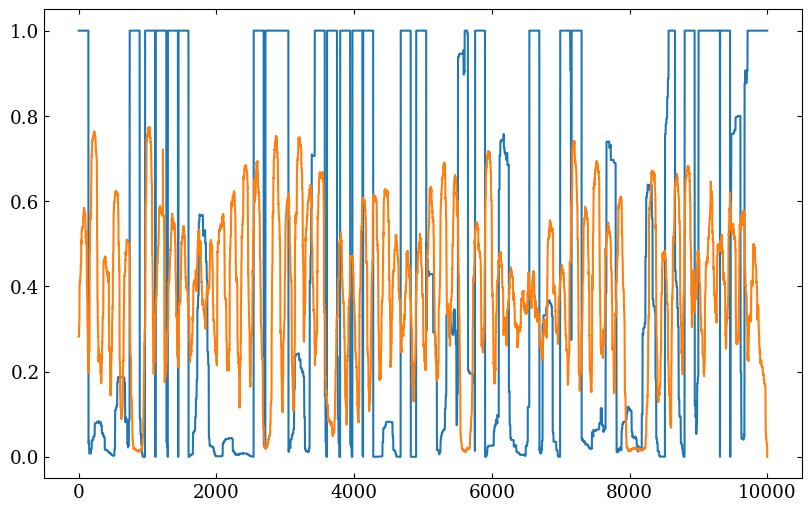

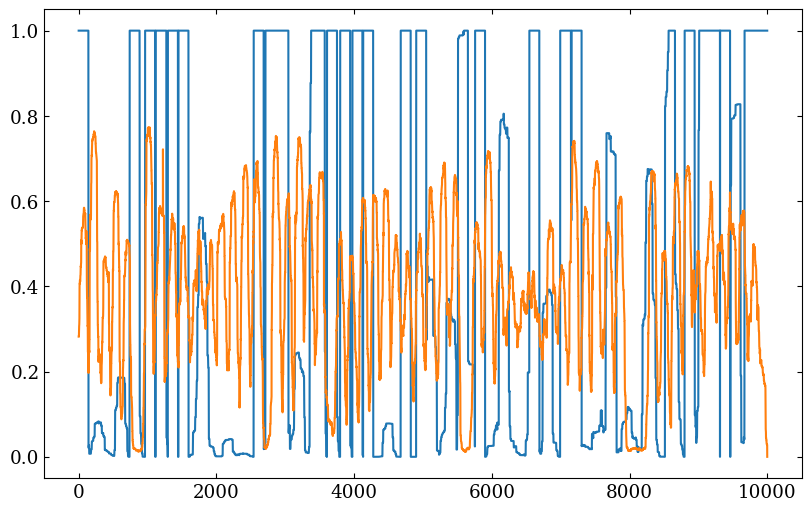

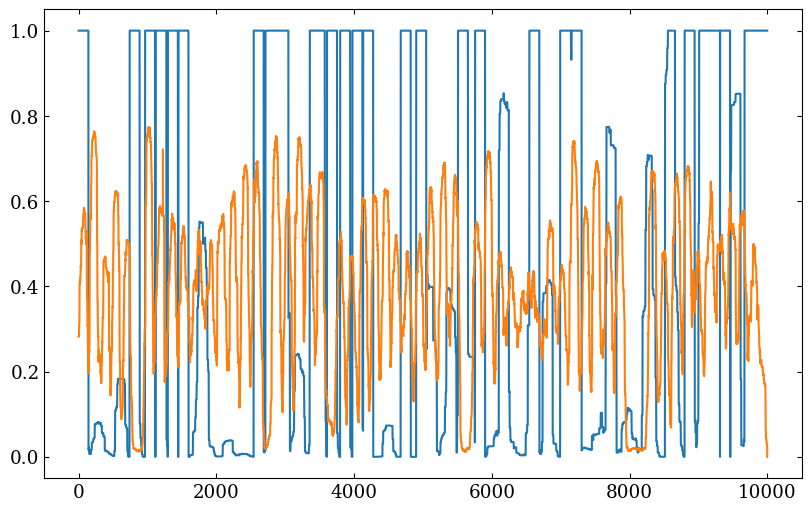

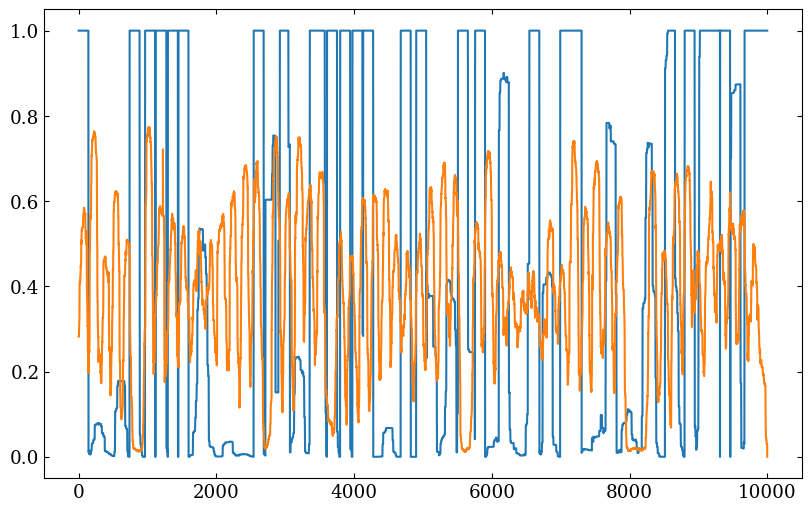

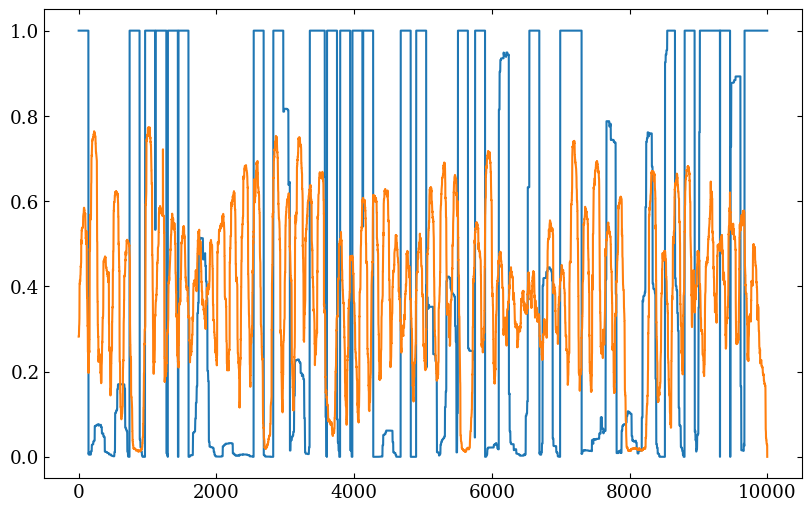

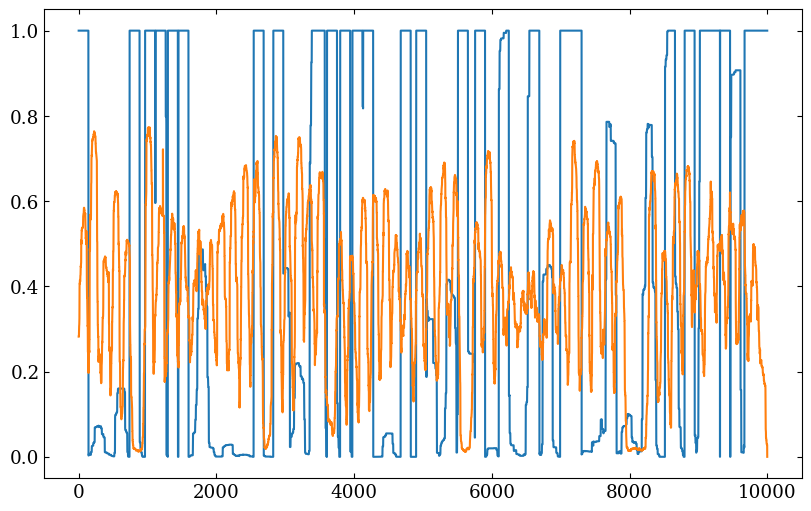

In [12]:
chem_pot = np.linspace(5, 40, 30)



for chem_p in chem_pot:
    amp = exp_func(chem_p, *fits["Exponential  a·e^(b·μ) + c"][1])
    fiber.calc_energy_landscape(period=10.5, amplitude=amp, chemical_potential=chem_p)
    lsq_occupancy = fiber.occupancy[1000:-1000]

    plotter = Plotter(fig_size=(8, 5))
    plotter.new(ncols=1, nrows=1)
    ax = plotter.axes
    
    ax.plot(fiber.occupancy[1000:-1000])
    ax.plot(occupancy)

